# Fig. 2B--D: H1N1 与 H3N2 手动数值图

本 notebook 生成两张图：一张 H1N1、一张 H3N2；每张都包含 titer、strain、serum 三个面板。MAE 柱状图使用 10 个随机 seed 的标准差作为误差线，Pearson 仅显示均值折线。

In [1]:
import matplotlib.pyplot as plt

# ===== 在此处手动填写数值 =====
# 每项顺序为 (MAE mean, MAE SD, Pearson mean)，并与 MODELS 顺序对应。
MODELS = ['FluAgPredictor', 'Nextflu', 'Adaboost']
COLORS = {'FluAgPredictor': '#C5DFF4', 'Nextflu': '#F4EEAC', 'Adaboost': '#C9DCC4', 'Vaxseer': '#F4B6C2'}
SPLIT_TITLES = {'titer': 'divided by titer', 'strain': 'divided by strain', 'serum': 'divided by serum'}

SUBTYPE_VALUES = {
    'H1N1': {
        'titer':  [(0.6716, 0.0047, 0.8498), (0.7978, 0.0039, 0.7780), (0.9551, 0.0112, 0.5643)],
        'strain': [(0.6929, 0.0110, 0.8349), (0.7993, 0.0108, 0.7709), (0.9425, 0.0342, 0.5771)],
        'serum':  [(0.8694, 0.2328, 0.7110), (0.7981, 0.0838, 0.7418), (0.8641, 0.2138, 0.6789)],
    },
    'H3N2': {
        'titer':  [(0.6959, 0.0053, 0.8602), (1.0847, 0.0120, 0.6554), (0.8351, 0.0089, 0.7440)],
        'strain': [(0.7187, 0.0066, 0.8517), (1.0935, 0.0135, 0.6491), (0.8407, 0.0143, 0.7396)],
        'serum':  [(0.9533, 0.0845, 0.7050), (1.2885, 0.1842, 0.5997), (1.0241, 0.1251, 0.6242)],
    },
}

# 设置为文件路径（如 'Fig2BCD_H1N1.svg'）即可保存；None 只显示。
OUTPUT_PATHS = {'H1N1': None, 'H3N2': None}


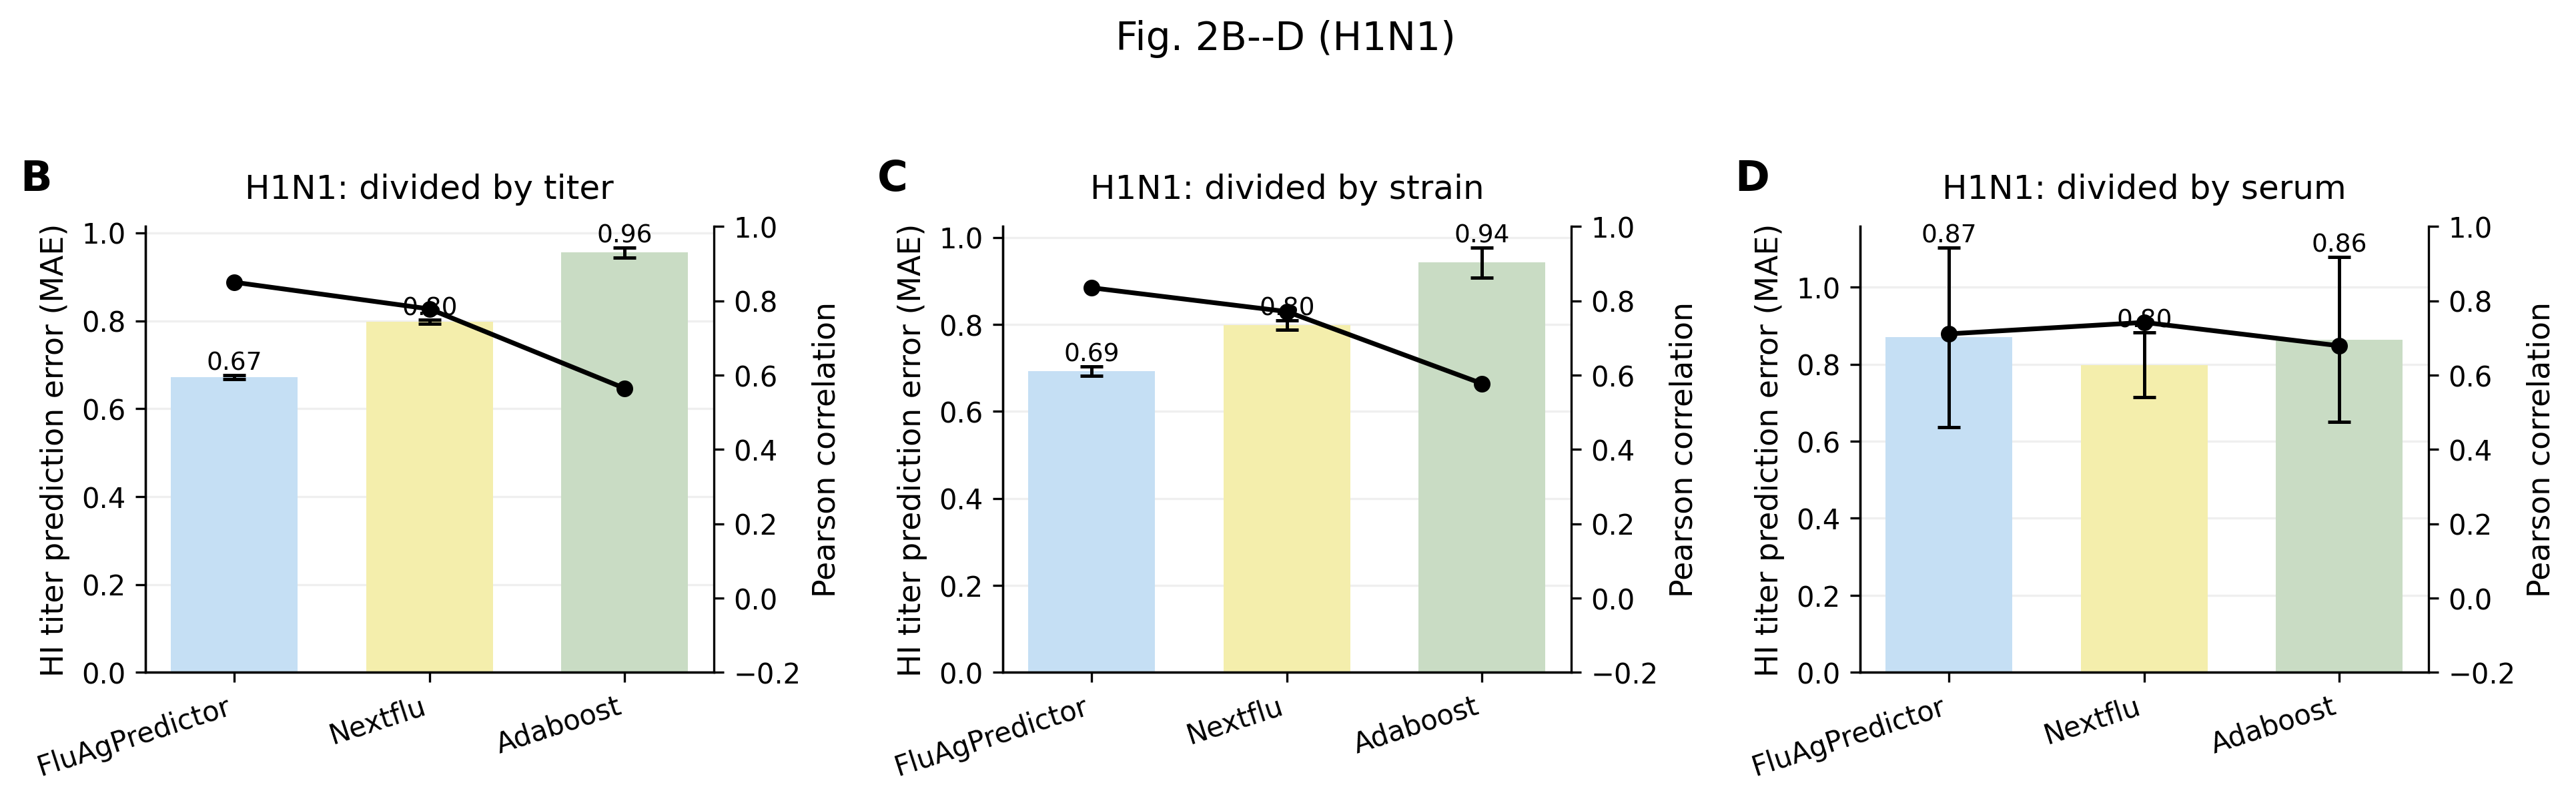

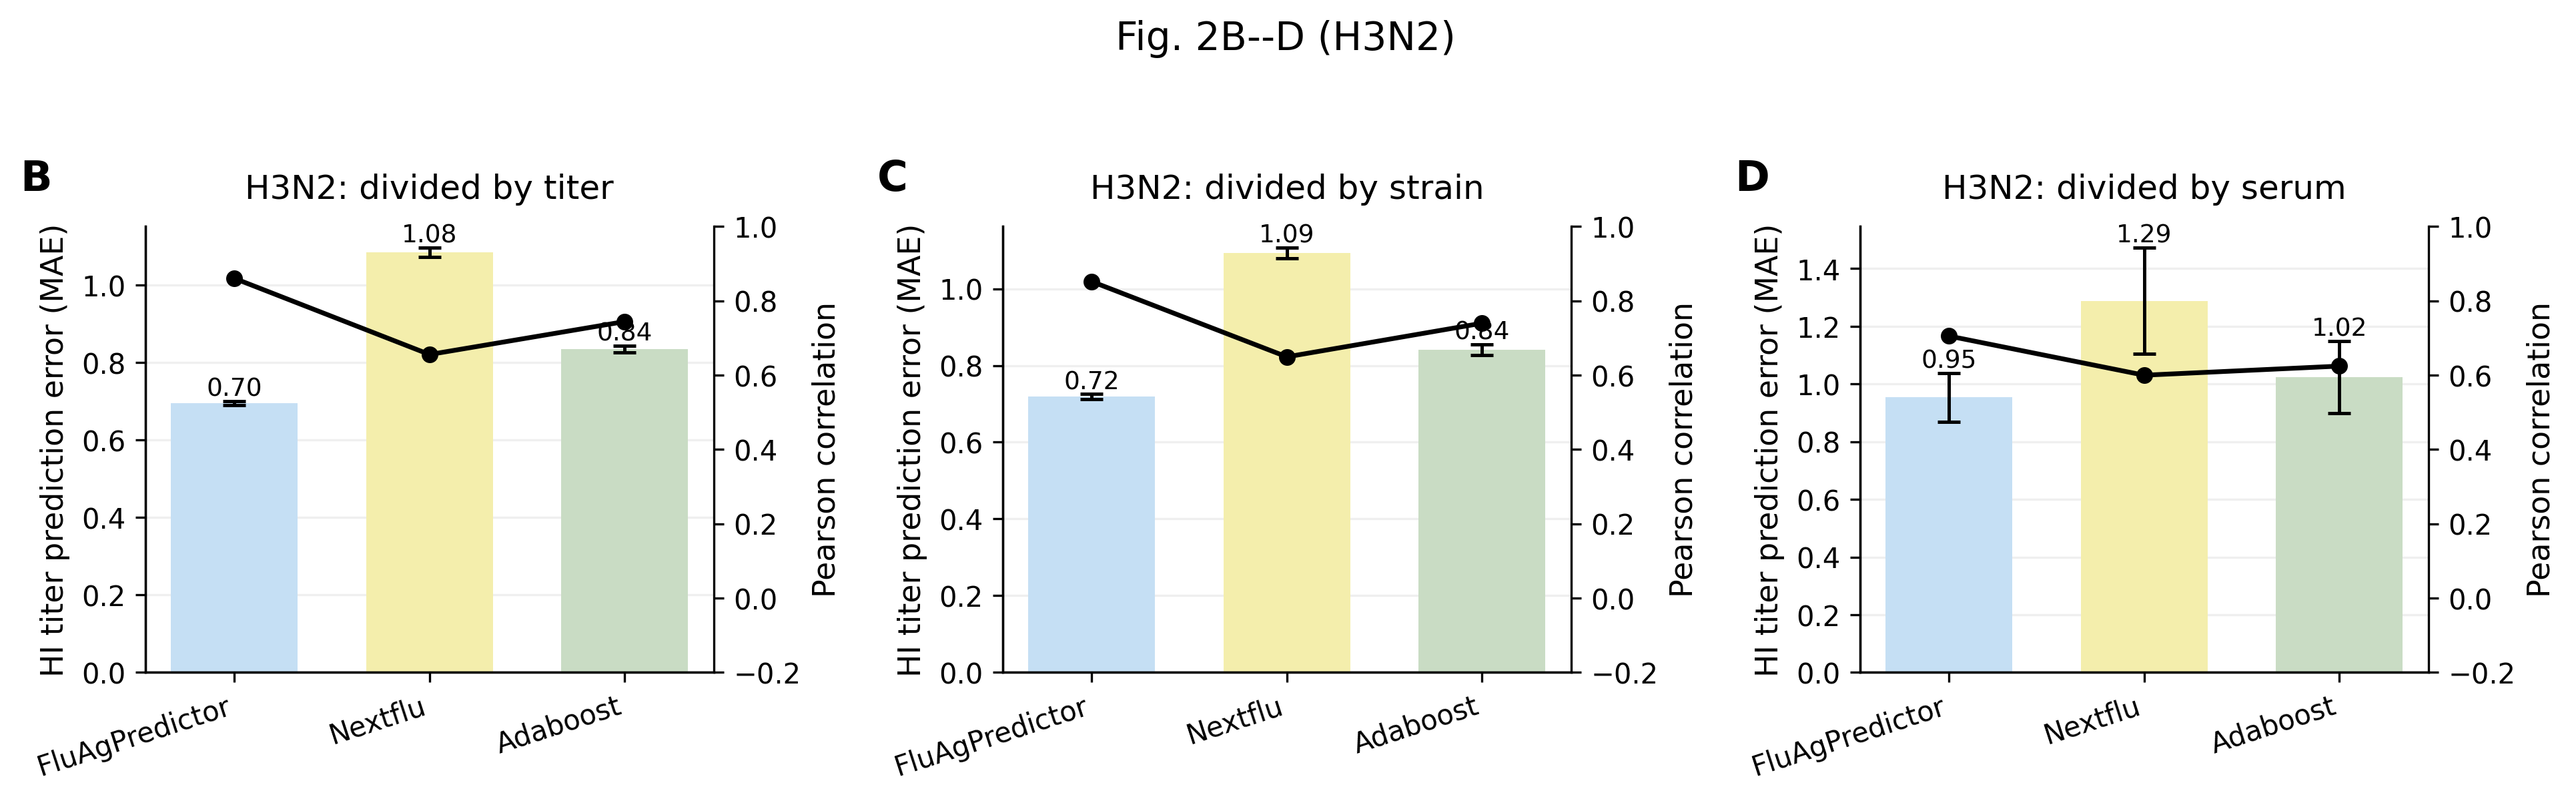

In [2]:
def plot_subtype_panels(subtype, values_by_split, output_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), dpi=300, sharey=False)
    for ax, split, panel_label in zip(axes, ('titer', 'strain', 'serum'), ['B', 'C', 'D']):
        values = values_by_split[split]
        if len(values) != len(MODELS):
            raise ValueError(f'{subtype}/{split} 的数值数量必须与 MODELS 数量一致。')
        mae_mean, mae_std, pearson_mean = map(list, zip(*values))
        x = list(range(len(MODELS)))
        bars = ax.bar(x, mae_mean, yerr=mae_std, color=[COLORS.get(model, '#BDBDBD') for model in MODELS],
                      width=0.65, capsize=4, error_kw={'elinewidth': 1.2, 'capthick': 1.2}, zorder=2)
        ax.set_title(f'{subtype}: {SPLIT_TITLES[split]}', fontsize=12, pad=10)
        ax.set_ylabel('HI titer prediction error (MAE)', fontsize=11)
        ax.set_xticks(x, MODELS, rotation=18, ha='right', fontsize=10)
        ax.tick_params(axis='y', labelsize=10)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.2, zorder=0)
        for bar, mean, std in zip(bars, mae_mean, mae_std):
            ax.text(bar.get_x() + bar.get_width() / 2, mean + std, f'{mean:.2f}', ha='center', va='bottom', fontsize=9)
        ax2 = ax.twinx()
        ax2.plot(x, pearson_mean, color='black', marker='o', linewidth=1.7, markersize=5, zorder=3)
        ax2.set_ylabel('Pearson correlation', fontsize=11)
        ax2.set_ylim(-0.2, 1.0); ax2.tick_params(axis='y', labelsize=10)
        ax2.spines['top'].set_visible(False)
        ax.text(-0.22, 1.08, panel_label, transform=ax.transAxes, fontsize=15, fontweight='bold')
    fig.suptitle(f'Fig. 2B--D ({subtype})', fontsize=14, y=1.04)
    fig.tight_layout()
    if output_path is not None:
        fig.savefig(output_path, bbox_inches='tight')
        print(f'Saved {subtype} figure to: {output_path}')
    plt.show()

for subtype in ('H1N1', 'H3N2'):
    plot_subtype_panels(subtype, SUBTYPE_VALUES[subtype], OUTPUT_PATHS[subtype])
